## Section 24 Feature Engineering

## Class 125- Handling Missing Value

In [3]:
import seaborn as sns

In [5]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
## Checking missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
df.shape

(891, 15)

In [13]:
## Delete the rows or data point to handle missing values
df.dropna().shape

(182, 15)

In [17]:
## Column wise deletion
df.dropna(axis=1) ## drop all Missing value/ NA column
# df.dropna(axis=1, inplace=True) to make permanent changes

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


## Imputation Missing Values
1. Mean Value Imputation

<Axes: xlabel='age', ylabel='Count'>

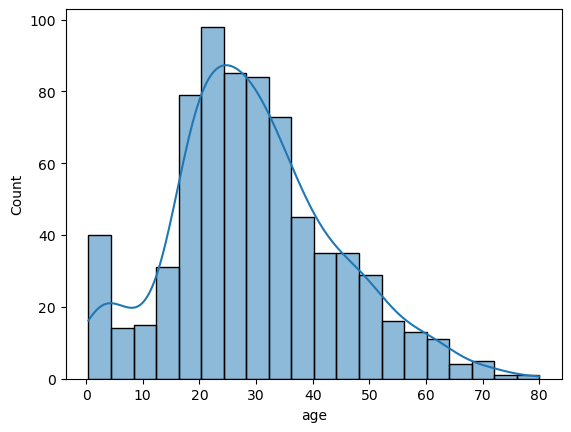

In [22]:
# sns.displot(df['age'])
sns.histplot(df['age'],kde=True)

In [28]:
df['Age_mean']=df['age'].fillna(df['age'].mean())
df[['Age_mean','age']]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [ ]:
## Mean Imputation Works Well when we have normally distributed data.

## 2. Median Value Imputation
If we have outliers present in the dataset.

In [31]:
df['Age_median']=df['age'].fillna(df['age'].median())
df[['Age_mean','Age_median','age']]

,Age_mean,Age_median,age
0,22.000000,22.0,22.0
1,38.000000,38.0,38.0
2,26.000000,26.0,26.0
3,35.000000,35.0,35.0
4,35.000000,35.0,35.0
...,...,...,...
886,27.000000,27.0,27.0
887,19.000000,19.0,19.0
888,29.699118,28.0,NaN
889,26.000000,26.0,26.0


## 3. Mode Imputation Technique
used for Categorical values

In [36]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,Age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [38]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [57]:
df[df['embarked'].notna()]['embarked'].mode()

0    S
Name: embarked, dtype: object

In [63]:
## Mode for embarked is S and its index is 0. Write mode index value in code
mode_value=df[df['embarked'].notna()]['embarked'].mode()[0]
mode_value

'S'

In [65]:
df['embarked_mode']=df['embarked'].fillna(mode_value)

In [78]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [80]:
df['embarked_mode'].isnull().sum()

0

In [82]:
df['embarked'].isnull().sum()

2

## Class 126- Handling Imbalanced Dataset

1. Up Sampling
2. Down Sampling

In [8]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.90
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [10]:
n_class_0, n_class_1

(900, 100)

In [12]:
# Create my Dataframe with Imbalanced dataset
class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'target' : [0]*n_class_0
})

class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_1' : np.random.normal(loc=2, scale=1, size=n_class_1),
    'target' : [1]*n_class_1
})

In [30]:
df=pd.concat([class_0, class_1]).reset_index(drop=True)

In [32]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [34]:
df.tail()

,feature_1,feature_2,target
995,2.845701,NaN,1
996,0.880077,NaN,1
997,1.640703,NaN,1
998,0.390305,NaN,1
999,2.013570,NaN,1


In [36]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [38]:
## upsampling
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [40]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True, #Sample with replacement
                                 n_samples=len(df_majority),
                                 random_state=42
                                )

In [42]:
df_minority_upsampled.shape

(900, 3)

In [44]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,1.843917,NaN,1
992,1.397425,NaN,1
914,2.998053,NaN,1
971,3.034197,NaN,1
960,1.550485,NaN,1


In [46]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [48]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

## 2. Down Sampling

In [52]:
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples*class_0_ratio)
n_class_1 = n_samples - n_class_0

class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2' : np.random.normal(loc=0, scale=1, size=n_class_0),
    'target' : [0]*n_class_0
})

class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2' : np.random.normal(loc=2, scale=1, size=n_class_1),
    'target' : [1]*n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

# Check the class distribution
print(df['target'].value_counts())


target
0    900
1    100
Name: count, dtype: int64


In [54]:
## downsampling
df_minority = df[df['target']==1]
df_majority = df[df['target']==0]

In [56]:
from sklearn.utils import resample
df_majority_downsampled = resample(df_majority, replace=False,
                                 n_samples=len(df_minority),
                                 random_state=42
                                )

In [62]:
df_majority_downsampled.shape

(100, 3)

In [64]:
df_downsampled = pd.concat([df_minority, df_majority_downsampled])

In [66]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

## Class 127- Handling Imbalanced Dataset using SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances.

SMOTE is used in classification problems where one class significantly outnumbers the others.

SMOTE is an oversampling method that creates synthetic samples of the minority class instead of simply duplicating existing one. This helps the model learn better decision boundaries and reduces the risk of overfitting.

SMOTE connects minority class points (closest/ neighbour points) with lines and places new synthetic points along those lines.

It presvents models from being biased towards the majority class. For each minority class sample, it finds k nearest neighbors. It randomly selects one of the neighbors and creates a new synthetic sample by interpolating between two points.

In [7]:
from sklearn.datasets import make_classification

In [9]:
x, y = make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90], random_state=12)
# x is input/ independent col and y is target or dependent col

In [11]:
import pandas as pd

df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [13]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

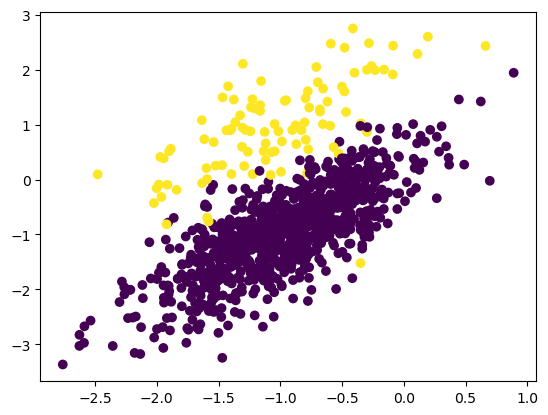

In [15]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [17]:
!pip install imblearn

In [19]:
from imblearn.over_sampling import SMOTE

In [21]:
## transform the dataset
oversample = SMOTE()
x, y = oversample.fit_resample(final_df[['f1','f2']], final_df['target'])

In [23]:
x.shape

(1800, 2)

In [29]:
y.shape

(1800,)

In [31]:
len(y[y==0])

900

In [33]:
len(y[y==1])

900

In [35]:
df1 = pd.DataFrame(x, columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['target'])
oversample_df = pd.concat([df1, df2], axis=1)

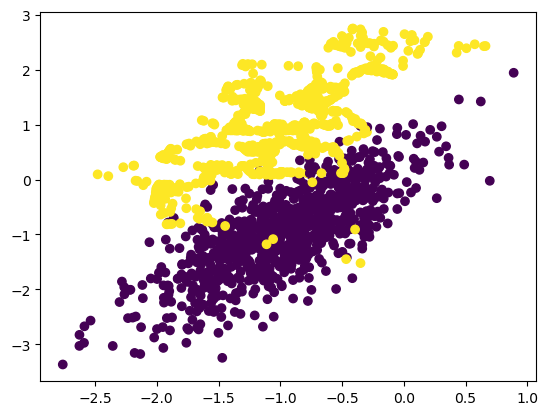

In [37]:
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])

## Class 128 - Handling Outliers Using Python
5 number Summary And Box Plot

In [ ]:
## Minimum, Maximum, Median, Q1, Q3, IQR

In [3]:
import numpy as np

In [5]:
lst_marks = [45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]
minimum, Q1, median, Q3, maximum = np.quantile(lst_marks, [0, 0.25, 0.50, 0.75, 1.0])

In [11]:
minimum, Q1, median, Q3, maximum

(32.0, 54.0, 67.0, 89.0, 99.0)

In [13]:
IQR = Q3-Q1
print(IQR)

35.0


In [15]:
lower_fence=Q1-1.5*(IQR)
higher_fence=Q3+1.5*(IQR)

In [17]:
lower_fence, higher_fence

(1.5, 141.5)

1. Any value lower than lower fence and any value which is higher than higher fence are outliers.
2. IQR (Interquartile Range) is a statistical method used to detect outliers in a dataset. It's especially useful when the data is not normally distributed or contains extreme values. The Interquartile Range (IQR) measures the spread of the middle 50% of a dataset. It is calculated as:
                            IQR=Q3-Q1
3. Any value

# BOX Plot

In [22]:
lst_marks = [45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]

In [24]:
import seaborn as sns

<Axes: >

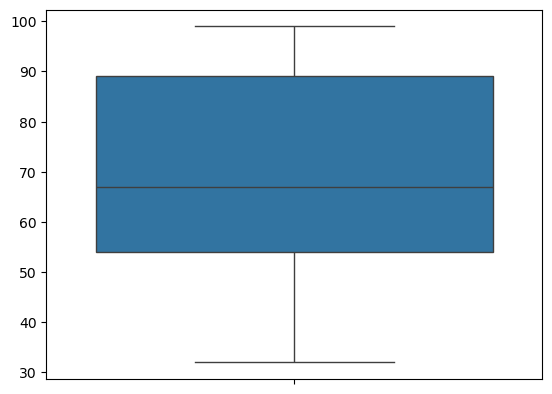

In [26]:
sns.boxplot(lst_marks)

<Axes: >

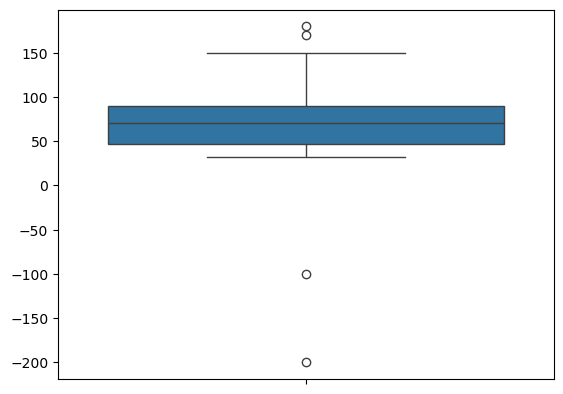

In [36]:
lst_marks = [-100,-200,45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74,150,170,180]
sns.boxplot(lst_marks)

## Class 129- Data Encoding- Nominal or OHE

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [3]:
##Creating a sample dataframe
df=pd.DataFrame({
    'color': ['red','blue','green','green','red','blue']
})

In [5]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [7]:
## create an instance of OneHotEncoder
encoder=OneHotEncoder()

In [15]:
##perform fit and tranform
encoded=encoder.fit_transform(df[['color']]).toarray()

In [19]:
import pandas as pd
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [21]:
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [27]:
#for new data
encoder.transform([['blue']]).toarray()

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [29]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [31]:
## Practice Data set
import seaborn as sns
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Class 130 Label And Ordinal Encoding
1. Label Encoding

In [34]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [36]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()

In [38]:
lbl_encoder.fit_transform(df[['color']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [40]:
lbl_encoder.transform([['red']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [42]:
lbl_encoder.transform([['blue']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

In [44]:
lbl_encoder.transform([['green']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([1])

## Ordinal Encoding

In [49]:
from sklearn.preprocessing import OrdinalEncoder

In [51]:
##create a sample dataframe with an ordinal variable
df=pd.DataFrame({
    'size':['small','medium','large','medium','small','large']
})

In [53]:
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [55]:
## create an instance of OrdinalEncoder and than fit_transform
encoder=OrdinalEncoder(categories=[['small','medium','large']])

In [59]:
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

In [61]:
## for new data
encoder.transform([['small']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[0.]])

In [63]:
encoder.transform([['large']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[2.]])

In [67]:
encoder.transform([['medium']])

C:\Users\rakhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[1.]])

## Class 131 Target Guided Ordinal Encoding